In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import pickle


In [3]:
Development = pd.read_csv(r"C:\Users\91939\Downloads\HDI.csv.csv")
Development.head()

,ISO3,Country,Human Development Groups,UNDP Developing Regions,HDI Rank (2021),Human Development Index (1990),Human Development Index (1991),Human Development Index (1992),Human Development Index (1993),Human Development Index (1994),...,Material footprint per capita (tonnes) (2012),Material footprint per capita (tonnes) (2013),Material footprint per capita (tonnes) (2014),Material footprint per capita (tonnes) (2015),Material footprint per capita (tonnes) (2016),Material footprint per capita (tonnes) (2017),Material footprint per capita (tonnes) (2018),Material footprint per capita (tonnes) (2019),Material footprint per capita (tonnes) (2020),Material footprint per capita (tonnes) (2021)
0,AFG,Afghanistan,Low,SA,180.0,0.273,0.279,0.287,0.297,0.292,...,1.86,1.88,1.66,1.62,1.66,1.41,1.32,1.38,1.38,1.38
1,AGO,Angola,Medium,SSA,148.0,NaN,NaN,NaN,NaN,NaN,...,4.09,4.53,3.97,3.59,2.79,2.64,2.28,2.18,2.18,2.18
2,ALB,Albania,High,ECA,67.0,0.647,0.629,0.614,0.617,0.624,...,12.44,11.49,13.14,12.61,14.39,14.46,12.85,12.96,12.96,12.96
3,AND,Andorra,Very High,NaN,40.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ARE,United Arab Emirates,Very High,AS,26.0,0.728,0.739,0.742,0.748,0.755,...,49.56,49.68,55.49,59.76,64.95,75.61,65.97,68.95,68.95,68.95


In [4]:
Development.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Columns: 880 entries, ISO3 to Material footprint per capita (tonnes) (2021)
dtypes: float64(876), object(4)
memory usage: 1.3+ MB


In [5]:
Development.shape

(195, 880)

In [6]:

Development.describe()


,HDI Rank (2021),Human Development Index (1990),Human Development Index (1991),Human Development Index (1992),Human Development Index (1993),Human Development Index (1994),Human Development Index (1995),Human Development Index (1996),Human Development Index (1997),Human Development Index (1998),...,Material footprint per capita (tonnes) (2012),Material footprint per capita (tonnes) (2013),Material footprint per capita (tonnes) (2014),Material footprint per capita (tonnes) (2015),Material footprint per capita (tonnes) (2016),Material footprint per capita (tonnes) (2017),Material footprint per capita (tonnes) (2018),Material footprint per capita (tonnes) (2019),Material footprint per capita (tonnes) (2020),Material footprint per capita (tonnes) (2021)
count,191.000000,141.000000,141.000000,141.000000,141.000000,141.000000,152.000000,152.000000,152.000000,152.000000,...,157.00000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000
mean,95.811518,0.599277,0.601979,0.604525,0.608504,0.613411,0.617625,0.623336,0.628599,0.634059,...,15.55535,15.675860,15.631146,15.637707,15.637834,15.798089,14.840000,15.019490,15.019490,15.019490
std,55.307333,0.164044,0.164100,0.164457,0.165456,0.166191,0.164990,0.165710,0.166592,0.167486,...,14.49240,14.930422,14.730498,15.063439,15.412834,15.739461,13.932553,14.644025,14.644025,14.644025
min,1.000000,0.216000,0.218000,0.222000,0.227000,0.232000,0.238000,0.243000,0.248000,0.256000,...,0.43000,0.420000,0.450000,0.560000,0.600000,0.610000,0.500000,0.470000,0.470000,0.470000
25%,48.500000,0.482000,0.484000,0.485000,0.485000,0.486000,0.486750,0.490750,0.492000,0.493000,...,4.53000,4.510000,4.350000,4.360000,4.420000,4.560000,4.590000,4.620000,4.620000,4.620000
50%,96.000000,0.628000,0.629000,0.627000,0.634000,0.639000,0.646500,0.653000,0.658000,0.664500,...,10.53000,10.370000,10.680000,10.020000,10.400000,10.740000,11.150000,10.620000,10.620000,10.620000
75%,143.500000,0.728000,0.729000,0.727000,0.731000,0.741000,0.745250,0.752000,0.759250,0.767000,...,20.90000,20.780000,20.750000,21.290000,19.790000,20.030000,18.960000,18.870000,18.870000,18.870000
max,191.000000,0.872000,0.873000,0.878000,0.880000,0.884000,0.885000,0.887000,0.890000,0.895000,...,74.56000,82.970000,81.100000,86.780000,83.510000,88.700000,71.160000,85.700000,85.700000,85.700000


In [7]:
Development.head()


,ISO3,Country,Human Development Groups,UNDP Developing Regions,HDI Rank (2021),Human Development Index (1990),Human Development Index (1991),Human Development Index (1992),Human Development Index (1993),Human Development Index (1994),...,Material footprint per capita (tonnes) (2012),Material footprint per capita (tonnes) (2013),Material footprint per capita (tonnes) (2014),Material footprint per capita (tonnes) (2015),Material footprint per capita (tonnes) (2016),Material footprint per capita (tonnes) (2017),Material footprint per capita (tonnes) (2018),Material footprint per capita (tonnes) (2019),Material footprint per capita (tonnes) (2020),Material footprint per capita (tonnes) (2021)
0,AFG,Afghanistan,Low,SA,180.0,0.273,0.279,0.287,0.297,0.292,...,1.86,1.88,1.66,1.62,1.66,1.41,1.32,1.38,1.38,1.38
1,AGO,Angola,Medium,SSA,148.0,NaN,NaN,NaN,NaN,NaN,...,4.09,4.53,3.97,3.59,2.79,2.64,2.28,2.18,2.18,2.18
2,ALB,Albania,High,ECA,67.0,0.647,0.629,0.614,0.617,0.624,...,12.44,11.49,13.14,12.61,14.39,14.46,12.85,12.96,12.96,12.96
3,AND,Andorra,Very High,NaN,40.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ARE,United Arab Emirates,Very High,AS,26.0,0.728,0.739,0.742,0.748,0.755,...,49.56,49.68,55.49,59.76,64.95,75.61,65.97,68.95,68.95,68.95


In [8]:
Development["Country"].unique()

array(['Afghanistan', 'Angola', 'Albania', 'Andorra',
       'United Arab Emirates', 'Argentina', 'Armenia',
       'Antigua and Barbuda', 'Australia', 'Austria', 'Azerbaijan',
       'Burundi', 'Belgium', 'Benin', 'Burkina Faso', 'Bangladesh',
       'Bulgaria', 'Bahrain', 'Bahamas', 'Bosnia and Herzegovina',
       'Belarus', 'Belize', 'Bolivia', 'Brazil', 'Barbados', 'Brunei',
       'Bhutan', 'Botswana', 'Central African Republic', 'Canada',
       'Switzerland', 'Chile', 'China', 'Ivory Coast', 'Cameroon',
       'The Democratic Republic of the Congo', 'Congo', 'Colombia',
       'Comoros', 'Cabo Verde', 'Costa Rica', 'Cuba', 'Cyprus', 'Czechia',
       'Germany', 'Djibouti', 'Dominica', 'Denmark', 'Dominican Republic',
       'Algeria', 'Ecuador', 'Egypt', 'Eritrea', 'Spain', 'Estonia',
       'Ethiopia', 'Finland', 'Fiji', 'France', 'Micronesia', 'Gabon',
       'United Kingdom', 'Georgia', 'Ghana', 'Guinea', 'Gambia',
       'Guinea-Bissau', 'Equatorial Guinea', 'Greece', 'Gren

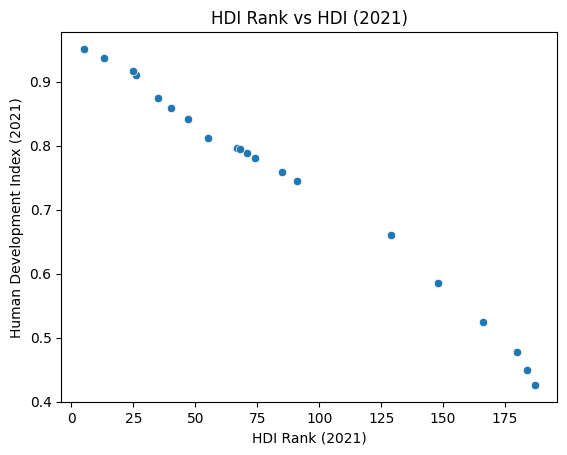

In [10]:
data1 = Development.head(20)

sns.scatterplot(
    x="HDI Rank (2021)",
    y="Human Development Index (2021)",
    data=data1
)

plt.title("HDI Rank vs HDI (2021)")
plt.show()

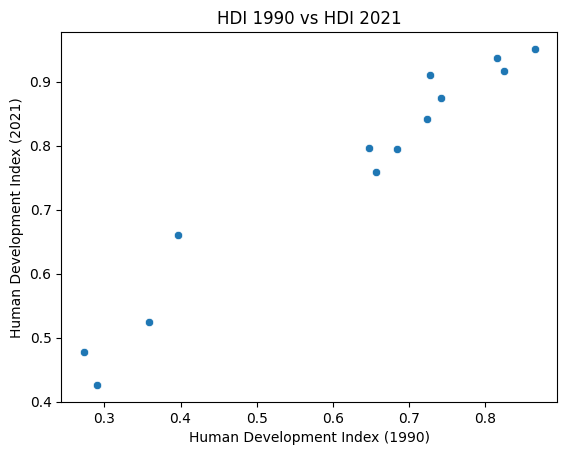

In [11]:
data1 = Development.head(20)

sns.scatterplot(
    x="Human Development Index (1990)",
    y="Human Development Index (2021)",
    data=data1
)

plt.title("HDI 1990 vs HDI 2021")
plt.show()

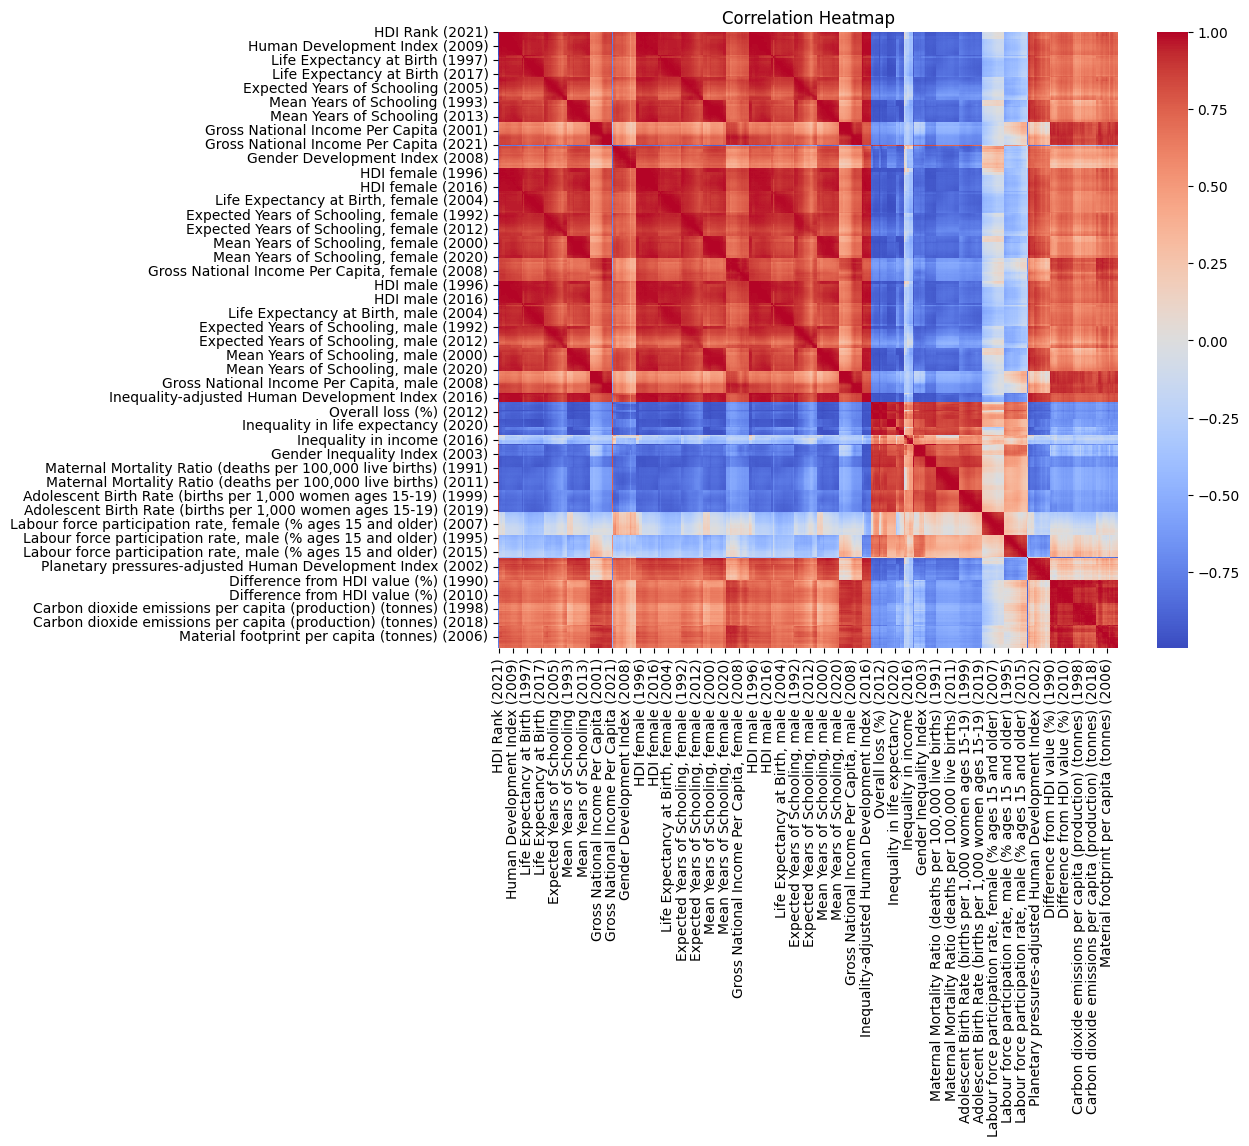

In [12]:
data1 = Development.head(20)

numeric_data = data1.select_dtypes(include="number")

plt.figure(figsize=(10,8))
sns.heatmap(numeric_data.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [13]:
print(Development.columns.tolist())

['ISO3', 'Country', 'Human Development Groups', 'UNDP Developing Regions', 'HDI Rank (2021)', 'Human Development Index (1990)', 'Human Development Index (1991)', 'Human Development Index (1992)', 'Human Development Index (1993)', 'Human Development Index (1994)', 'Human Development Index (1995)', 'Human Development Index (1996)', 'Human Development Index (1997)', 'Human Development Index (1998)', 'Human Development Index (1999)', 'Human Development Index (2000)', 'Human Development Index (2001)', 'Human Development Index (2002)', 'Human Development Index (2003)', 'Human Development Index (2004)', 'Human Development Index (2005)', 'Human Development Index (2006)', 'Human Development Index (2007)', 'Human Development Index (2008)', 'Human Development Index (2009)', 'Human Development Index (2010)', 'Human Development Index (2011)', 'Human Development Index (2012)', 'Human Development Index (2013)', 'Human Development Index (2014)', 'Human Development Index (2015)', 'Human Development Ind

In [16]:
X = Development[[
    'Life Expectancy at Birth (2021)',
    'Expected Years of Schooling (2021)',
    'Mean Years of Schooling (2021)',
    'Gross National Income Per Capita (2021)'
]]

y = Development['HDI Rank (2021)']

X = pd.DataFrame(X)
y = pd.DataFrame(y)

X.head()

,Life Expectancy at Birth (2021),Expected Years of Schooling (2021),Mean Years of Schooling (2021),Gross National Income Per Capita (2021)
0,61.9824,10.263844,2.985070,1824.190915
1,61.6434,12.172100,5.417391,5465.617791
2,76.4626,14.448000,11.286455,14131.110390
3,80.3684,13.300239,10.555120,51166.626610
4,78.7104,15.717690,12.694030,62573.591810


In [17]:
X.isnull().sum()

Life Expectancy at Birth (2021)            0
Expected Years of Schooling (2021)         2
Mean Years of Schooling (2021)             4
Gross National Income Per Capita (2021)    2
dtype: int64

In [18]:
X.fillna(X.mean(numeric_only=True), inplace=True)

In [19]:
X.isnull().sum()

Life Expectancy at Birth (2021)            0
Expected Years of Schooling (2021)         0
Mean Years of Schooling (2021)             0
Gross National Income Per Capita (2021)    0
dtype: int64

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.1,random_state=42
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (175, 4)
X_test shape: (20, 4)
y_train shape: (175, 1)
y_test shape: (20, 1)


In [22]:
y.isnull().sum()

HDI Rank (2021)    4
dtype: int64

In [23]:
y.fillna(y.mean(), inplace=True)

In [24]:
y.isnull().sum()

HDI Rank (2021)    0
dtype: int64

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.1,random_state=42
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (175, 4)
X_test shape: (20, 4)
y_train shape: (175, 1)
y_test shape: (20, 1)


In [26]:
reg = LinearRegression()
reg.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [27]:
y_pred = reg.predict(X_test)
print("Predicted Values:")
print(y_pred)
print("\nActual Values:")
print(y_test.values)

Predicted Values:
[[107.69265218]
 [ 75.83242293]
 [173.84036569]
 [148.9250036 ]
 [ 25.21446423]
 [  0.27829603]
 [173.29830343]
 [118.08366812]
 [ 89.84565381]
 [ 98.94859546]
 [ 15.33886214]
 [ 69.62511473]
 [ -4.70127251]
 [ 24.88957219]
 [ 22.18865969]
 [144.76455222]
 [ 65.10193054]
 [120.71439174]
 [ 99.18931033]
 [ 90.97938415]]

Actual Values:
[[116.]
 [ 68.]
 [181.]
 [140.]
 [ 33.]
 [ 12.]
 [175.]
 [129.]
 [ 86.]
 [ 90.]
 [ 21.]
 [ 55.]
 [  3.]
 [ 25.]
 [ 23.]
 [149.]
 [ 68.]
 [131.]
 [109.]
 [ 96.]]


In [28]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Squared Error: 61.786331649405916
Root Mean Squared Error: 7.860428210308005
R2 Score: 0.9786734095060988


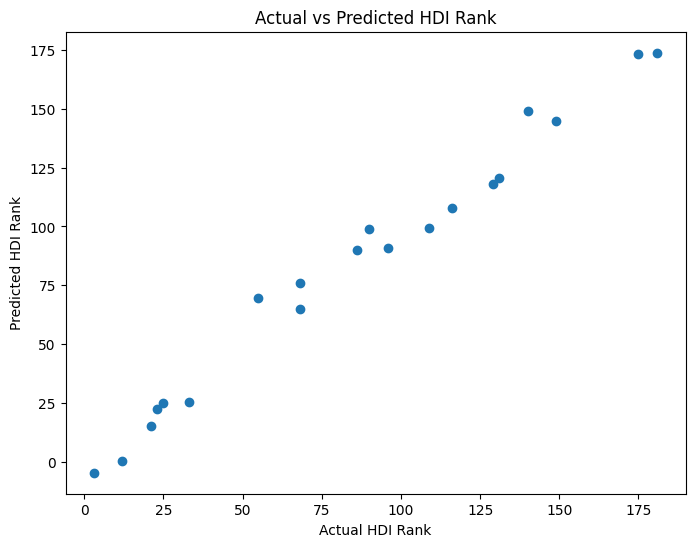

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual HDI Rank")
plt.ylabel("Predicted HDI Rank")
plt.title("Actual vs Predicted HDI Rank")
plt.show()

In [30]:
import pickle

pickle.dump(reg, open("HDI.pkl", "wb"))

print("Model saved successfully!")

Model saved successfully!
